# Bagian 5 | Eksperimen RNN

In [ ]:
import os
import sys
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from nltk.translate.bleu_score import corpus_bleu

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.abspath(""), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.rnn.RNNKeras import RNNKeras
from src.rnn.RNNScratch import RNNScratch

metadata_path = os.path.join(PROJECT_ROOT, "outputs", "vocab", "metadata.json")
vocab_path = os.path.join(PROJECT_ROOT, "outputs", "vocab", "vocab.json")
test_txt = os.path.join(PROJECT_ROOT, "data", "Flickr_8k.testImages.txt")
images_dir = os.path.join(PROJECT_ROOT, "data", "Images")
captions_file = os.path.join(PROJECT_ROOT, "data", "captions.txt")
models_dir = os.path.join(PROJECT_ROOT, "models", "rnn")
output_dir = os.path.join(PROJECT_ROOT, "outputs")

with open(vocab_path, "r") as f:
    word_to_idx = json.load(f)
idx_to_word = {str(idx): word for word, idx in word_to_idx.items()}

with open(test_txt, "r") as f:
    test_images = [line.strip() for line in f if line.strip()]
sample_images = [img for img in test_images if os.path.exists(os.path.join(images_dir, img))]

def load_captions(captions_file):
    image_captions = {}
    with open(captions_file, "r", encoding="utf-8") as f:
        next(f)
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(",", 1)
            if len(parts) == 2:
                img, cap = parts
                if img not in image_captions:
                    image_captions[img] = []
                image_captions[img].append(cap)
    return image_captions

image_captions = load_captions(captions_file)


## 1. Perbandingan Keras vs Scratch
Membandingkan prediksi yang dihasilkan oleh model **Keras Native** dan implementasi **From Scratch**.


In [ ]:
model_name = "rnn_L1_H512" 
model_path = os.path.join(models_dir, model_name, f"{model_name}.keras")

try:
    keras_model = RNNKeras(model_path, metadata_path)
    scratch_model = RNNScratch(model_path, metadata_path)
    print("Berhasil memuat model Keras dan Scratch!")
except Exception as e:
    print(f"Gagal memuat model. Pastikan model {model_name} sudah selesai di-training.")
    print("Error:", e)


Encoder: INCEPTIONV3 — output dim: 2048
Encoder: INCEPTIONV3 — output dim: 2048
Berhasil memuat model Keras dan Scratch!


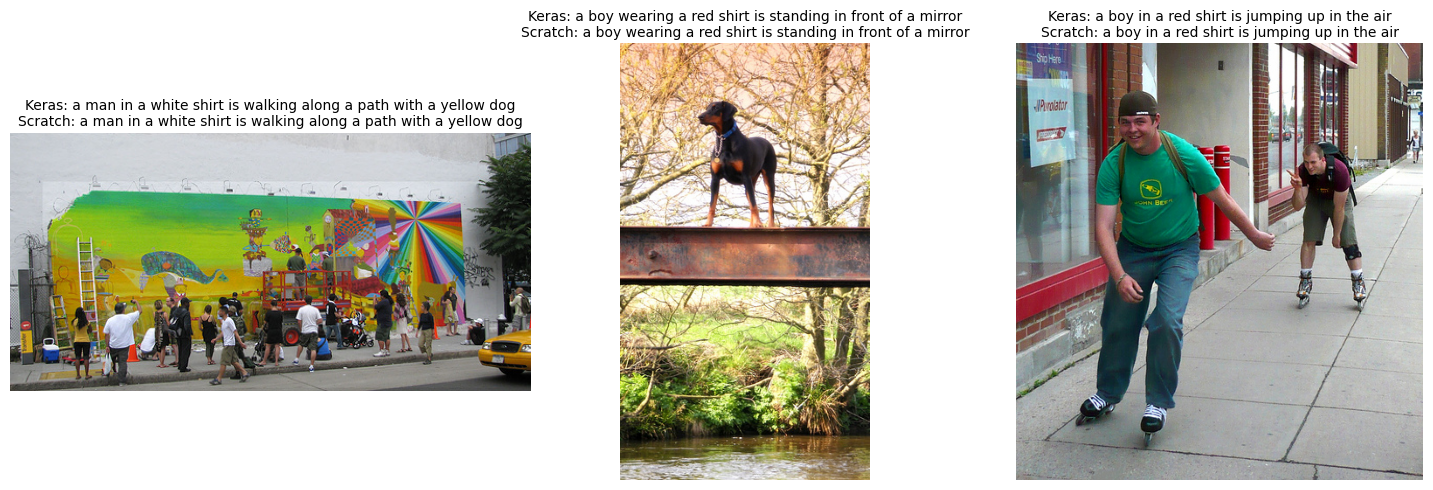

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
random.seed(42)

for ax in axes:
    img_name = random.choice(sample_images)
    img_path = os.path.join(images_dir, img_name)
    
    # Generate captions
    cap_keras = keras_model.generate_caption(img_path, idx_to_word)
    cap_scratch = scratch_model.generate_caption(img_path, idx_to_word)
    
    # Ground Truths
    gts = "\n".join([f"- {c}" for c in image_captions[img_name][:3]])
    
    # Plotting
    img_data = mpimg.imread(img_path)
    ax.imshow(img_data)
    ax.axis('off')
    
    title = f"Keras: {cap_keras}\nScratch: {cap_scratch}"
    ax.set_title(title, fontsize=10, wrap=True)
    
plt.tight_layout()
plt.show()


In [ ]:
# Perbandingan BLEU-4 dan waktu eksekusi Keras vs Scratch
eval_images = sample_images

references = []
for img in eval_images:
    img_refs = [cap.lower().replace('.', '').replace(',', '').split()
                for cap in image_captions[img]]
    references.append(img_refs)

keras_vs_scratch_results = []

for name, model in [('Keras', keras_model), ('Scratch', scratch_model)]:
    hypotheses = []
    start_time = time.time()

    for img in eval_images:
        img_path = os.path.join(images_dir, img)
        caption  = model.generate_caption(img_path, idx_to_word)
        words    = [w for w in caption.split() if w not in ['<start>', '<end>', '<pad>']]
        hypotheses.append(words)

    total_time = time.time() - start_time
    avg_time   = total_time / len(eval_images)
    bleu4      = corpus_bleu(references, hypotheses)

    keras_vs_scratch_results.append({'model': name, 'bleu4': bleu4, 'avg_time_s': avg_time})
    print(f'[{name}] BLEU-4: {bleu4:.4f} | Waktu/img: {avg_time:.4f}s')

out_json = os.path.join(output_dir, 'experiment_keras_vs_scratch_lstm.json')
with open(out_json, 'w') as f:
    json.dump(keras_vs_scratch_results, f, indent=4)
print(f'Tersimpan di {out_json}')


## 2. Eksperimen 6 Variasi Arsitektur
Menjalankan evaluasi BLEU-4 dan perhitungan waktu inferensi untuk 6 variasi Hyperparameter (Layer x Hidden Units).


In [ ]:
def evaluate_models(num_samples=100):
    eval_images = sample_images[:num_samples]
    
    # Setup references (Ground Truths)
    references = []
    for img in eval_images:
        img_refs = []
        for cap in image_captions[img]:
            img_refs.append(cap.lower().replace(".", "").replace(",", "").split())
        references.append(img_refs)

    configs = [
        "rnn_L1_H128", "rnn_L1_H512",
        "rnn_L2_H128", "rnn_L2_H512",
        "rnn_L3_H128", "rnn_L3_H512"
    ]
    
    results = []
    
    for config in configs:
        model_path = os.path.join(models_dir, config, f"{config}.keras")
        if not os.path.exists(model_path):
            print(f"Model {config} tidak ditemukan. Skip.")
            continue
            
        print(f"Mengevaluasi {config}...")
        captioner = RNNScratch(model_path, metadata_path)
        
        hypotheses = []
        start_time = time.time()
        
        for img in eval_images:
            img_path = os.path.join(images_dir, img)
            caption = captioner.generate_caption(img_path, idx_to_word)
            
            # Remove special tokens for BLEU
            words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
            hypotheses.append(words)
            
        total_time = time.time() - start_time
        avg_time = total_time / len(eval_images)
        bleu4 = corpus_bleu(references, hypotheses)
        
        results.append({
            "config": config,
            "bleu4": bleu4,
            "avg_inference_time_s": avg_time
        })
        
    print("\nHasil Evaluasi:")
    for r in results:
        print(f"{r['config']:<15} | BLEU-4: {r['bleu4']:.4f} | Waktu/img: {r['avg_inference_time_s']:.4f}s")
        
    # Simpan hasil
    os.makedirs(output_dir, exist_ok=True)
    out_json = os.path.join(output_dir, "results", "experiment_6_rnn_variations.json")
    
    with open(out_json, "w") as f:
        json.dump(results, f, indent=4)
    print(f"Tersimpan di {out_json}")

# Jalankan pada 100 sampel agar cepat, ganti num_samples=len(sample_images) untuk evaluasi penuh
evaluate_models(num_samples=len(sample_images))


Mengevaluasi rnn_L1_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L1_H512...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L2_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L2_H512...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L3_H128...
Encoder: INCEPTIONV3 — output dim: 2048
Mengevaluasi rnn_L3_H512...
Encoder: INCEPTIONV3 — output dim: 2048

Hasil Evaluasi:
rnn_L1_H128     | BLEU-4: 0.0599 | Waktu/img: 0.1873s
rnn_L1_H512     | BLEU-4: 0.0632 | Waktu/img: 0.3195s
rnn_L2_H128     | BLEU-4: 0.0342 | Waktu/img: 0.2421s
rnn_L2_H512     | BLEU-4: 0.0288 | Waktu/img: 0.3038s
rnn_L3_H128     | BLEU-4: 0.0721 | Waktu/img: 0.2193s
rnn_L3_H512     | BLEU-4: 0.0478 | Waktu/img: 0.3279s
Tersimpan di c:\Users\Alfansya\OneDrive\Documents\Kuliah\Semester_6\ML\CNN_RNN_LSTM\outputs\experiment_6_rnn_variations.json


## 3. Visualisasi Hasil Eksperimen

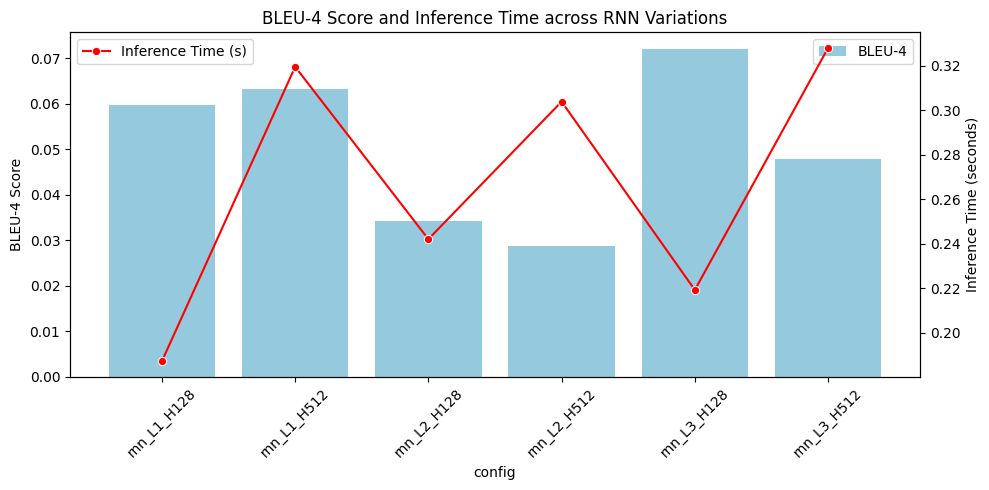

In [ ]:
import pandas as pd
import seaborn as sns

res_path = os.path.join(output_dir, "results", "experiment_6_rnn_variations.json")
if os.path.exists(res_path):
    with open(res_path, 'r') as f:
        data = json.load(f)
        
    df = pd.DataFrame(data)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Bar plot for BLEU-4
    sns.barplot(data=df, x='config', y='bleu4', color='skyblue', ax=ax1, label='BLEU-4')
    ax1.set_ylabel('BLEU-4 Score')
    ax1.tick_params(axis='x', rotation=45)
    
    # Line plot for Inference Time
    ax2 = ax1.twinx()
    sns.lineplot(data=df, x='config', y='avg_inference_time_s', color='red', marker='o', ax=ax2, label='Inference Time (s)')
    ax2.set_ylabel('Inference Time (seconds)')
    
    plt.title('BLEU-4 Score and Inference Time across RNN Variations')
    # fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()
else:
    print("Belum ada data evaluasi. Jalankan sel sebelumnya dulu.")


## 4. Evaluasi Pengaruh Maksimum Panjang Caption (Max Length)

In [13]:
def evaluate_max_lengths(num_samples=100):
    eval_images = sample_images[:num_samples]
    
    references = []
    for img in eval_images:
        img_refs = []
        for cap in image_captions[img]:
            img_refs.append(cap.lower().replace(".", "").replace(",", "").split())
        references.append(img_refs)

    # Gunakan Keras model untuk pengujian max length karena lebih cepat
    max_lengths = [10, 20, 30]
    results = []
    
    for max_len in max_lengths:
        hypotheses = []
        print(f"Mengevaluasi max_length={max_len}...")
        
        for img in eval_images:
            img_path = os.path.join(images_dir, img)
            caption = keras_model.generate_caption(img_path, idx_to_word, max_len=max_len)
            
            words = [w for w in caption.split() if w not in ["<start>", "<end>", "<pad>"]]
            hypotheses.append(words)
            
        bleu4 = corpus_bleu(references, hypotheses)
        results.append({
            "max_len": max_len,
            "bleu4": bleu4,
        })
        
    print("\nHasil Evaluasi Max Length:")
    for r in results:
        print(f"Max Len: {r['max_len']} | BLEU-4: {r['bleu4']:.4f}")
        
    out_json = os.path.join(output_dir, "experiment_max_len_rnn.json")
    with open(out_json, "w") as f:
        json.dump(results, f, indent=4)
        
evaluate_max_lengths(num_samples=100)


Mengevaluasi max_length=10...
Mengevaluasi max_length=20...
Mengevaluasi max_length=30...

Hasil Evaluasi Max Length:
Max Len: 10 | BLEU-4: 0.0390
Max Len: 20 | BLEU-4: 0.0333
Max Len: 30 | BLEU-4: 0.0333
